In [ ]:
!pip install numpy pandas matplotlib scipy scikit-learn tensorflow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [ ]:
#STEP 2: Load Data
COVID_URL = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

df = pd.read_csv(COVID_URL)
df = df[df['location'] == 'India']

df = df[['date', 'new_cases', 'population']]
df = df.dropna()
df = df[df['new_cases'] > 0]

df.reset_index(drop=True, inplace=True)

population = df['population'].iloc[0]
cases = df['new_cases'].values

In [ ]:
#STEP 3: SEIRD MODEL (CLEAN)
def seird_model(y, t, beta, sigma, gamma, mu):
    S, E, I, R, D = y

    dS = -beta * S * I
    dE = beta * S * I - sigma * E
    dI = sigma * E - gamma * I - mu * I
    dR = gamma * I
    dD = mu * I

    return [dS, dE, dI, dR, dD]

In [ ]:
#STEP 4: INITIAL CONDITIONS
I0 = cases[0] / population
E0 = I0 * 2
R0 = 0
D0 = 0
S0 = 1 - (I0 + E0)

y0 = [S0, E0, I0, R0, D0]

In [ ]:
#STEP 5: SOLVE SEIRD
t = np.arange(len(cases))

beta = 0.3
sigma = 0.2
gamma = 0.1
mu = 0.01

solution = odeint(seird_model, y0, t, args=(beta, sigma, gamma, mu))

S, E, I, R, D = solution.T

seird_pred = I * population  # convert to real scale

In [ ]:
#STEP 6: LSTM PREP (CORRECT WAY)
scaler = MinMaxScaler()
cases_scaled = scaler.fit_transform(cases.reshape(-1,1))

In [ ]:
#STEP 7: CREATE SEQUENCES
def create_sequences(data, seq_len=14):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(cases_scaled)

In [ ]:
#STEP 8: TRAIN TEST SPLIT
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
#STEP 9: BUILD LSTM (STABLE)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, input_shape=(14,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=16)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0396
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0290
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0264
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0239
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0222
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0200
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0187
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0171
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0161
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0152


In [ ]:
#STEP 10: LSTM PREDICTION (FIXED)
pred_scaled = model.predict(X_test)

# convert back properly
pred = scaler.inverse_transform(pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 497ms/step


In [ ]:
#STEP 11: ALIGN MODELS (CRITICAL FIX)
start_index = split + 14

seird_aligned = seird_pred[start_index : start_index + len(pred)]

y_true = y_test_actual.flatten()
lstm_pred = pred.flatten()
seird_pred = seird_aligned.flatten()

In [ ]:
#STEP 12: HYBRID MODEL
best_alpha = 0
best_rmse = float('inf')

for alpha in np.linspace(0,1,21):
    hybrid = alpha * seird_pred + (1-alpha) * lstm_pred

    rmse = np.sqrt(mean_squared_error(y_true, hybrid))

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

hybrid_pred = best_alpha * seird_pred + (1-best_alpha) * lstm_pred

print("Best Alpha:", best_alpha)
print("Best RMSE:", best_rmse)

Best Alpha: 0.0
Best RMSE: 148547.8473709043


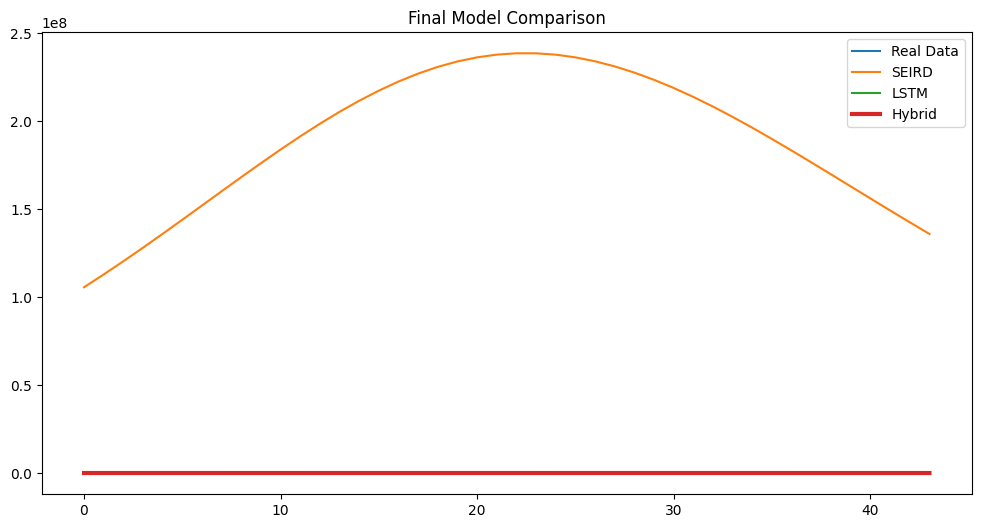

In [ ]:
#STEP 13: FINAL PLOT
plt.figure(figsize=(12,6))

plt.plot(y_true, label='Real Data')
plt.plot(seird_pred, label='SEIRD')
plt.plot(lstm_pred, label='LSTM')
plt.plot(hybrid_pred, label='Hybrid', linewidth=3)

plt.legend()
plt.title("Final Model Comparison")
plt.show()

In [ ]:
rmse_seird = np.sqrt(mean_squared_error(y_true, seird_pred))
rmse_lstm = np.sqrt(mean_squared_error(y_true, lstm_pred))
rmse_hybrid = np.sqrt(mean_squared_error(y_true, hybrid_pred))

print("SEIRD RMSE:", rmse_seird)
print("LSTM RMSE:", rmse_lstm)
print("HYBRID RMSE:", rmse_hybrid)

SEIRD RMSE: 194337072.10120445
LSTM RMSE: 148547.8473709043
HYBRID RMSE: 148547.8473709043
